# Unscented Transform for Non-Linear Time Propagation

## Learning Objectives
- Demonstrate the effectiveness of the Unscented Transform (UT) for covariance propagation over time in a completely non-linear dynamic system.
- Understand how EKF's linearization fails over multiple time steps, leading to an over-confident or misaligned covariance representation.
- Visualize the development of "banana-shaped" probability distributions in highly non-linear kinematics.

---

## 1. Theory Recap

In dynamic systems, the state $x$ evolves over time according to a non-linear process model:
$$x_{k} = f(x_{k-1}, u_{k-1}) + w_{k-1}$$

To predict the state's mean and covariance forward in time:
- **Extended Kalman Filter (predict step)**: Linearizes $f$ around the current mean $\hat{x}_{k-1}$ using the Jacobian matrix $F$. The covariance propagates as $P_k = F P_{k-1} F^T + Q$. Over multiple steps of high non-linearity, this repeatedly truncated 1st-order approximation compounds error and forces the distribution to remain a simple ellipse in the $x-y$ plane.
- **Unscented Transform (predict step)**: Passes deterministically chosen sigma points $\sigma_i$ through the actual non-linear function $f(\hat{x}_{k-1} + \sigma_i)$. Their weighted statistics recreate the true predicted mean and covariance identically matching the Taylor series up to the 2nd order, allowing it to capture complex shapes like "bananas".

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky

np.random.seed(42) # For reproducibility

## 2. Defining the Non-Linear Dynamic System (Unicycle Model)

We will use a standard 2D kinematic Unicycle model (Constant Turn Rate and Velocity).
The state is $\mathbf{x} = [p_x, p_y, \theta]^T$, representing 2D position and heading angle.
Control inputs are known and constant: $\mathbf{u} = [v, \omega]^T$ (forward velocity and turn rate).

The discrete-time non-linear propagation equations are:
$$ p_{x, k} = p_{x, k-1} + v \cdot \cos(\theta_{k-1}) \Delta t $$
$$ p_{y, k} = p_{y, k-1} + v \cdot \sin(\theta_{k-1}) \Delta t $$
$$ \theta_{k} = \theta_{k-1} + \omega \Delta t $$

Process noise $w_k \sim \mathcal{N}(0, Q)$ is added at each step.

The high uncertainty in heading $\theta$ will cause the positional covariance to warp into a banana shape over time.

In [2]:
# Dynamics parameters
dt = 0.1
v = 10.0   # Constant velocity
omega = 0.1 # Constant turn rate
time_steps = 50

# 1. Non-linear state transition function f(x)
def unicycle_kinematics(state):
    """Propagates the unicycle state [x, y, theta] forward by dt"""
    x, y, theta = state[0], state[1], state[2]
    
    next_x = x + v * np.cos(theta) * dt
    next_y = y + v * np.sin(theta) * dt
    next_theta = theta + omega * dt
    
    return np.array([next_x, next_y, next_theta])

# 2. Jacobian of the kinematics for the EKF
def unicycle_jacobian(state):
    """Calculates the Jacobian F matrix"""
    x, y, theta = state[0], state[1], state[2]
    
    F = np.array([
        [1.0, 0.0, -v * np.sin(theta) * dt],
        [0.0, 1.0,  v * np.cos(theta) * dt],
        [0.0, 0.0,  1.0]
    ])
    return F

# 3. Initial state distribution
# Perfect position knowledge, but highly uncertain heading
initial_mean = np.array([0.0, 0.0, np.pi/2])  # Starting at origin, facing North
initial_cov = np.diag([0.1**2, 0.1**2, 0.01**2])


# 4. Process noise covariance Q
Q = np.diag([0.05**2, 0.05**2, 0.01**2])

## 3. Actual Transformation (Monte Carlo Simulation)
We'll pass 5,000 random samples through the non-linear dynamics iteratively for 20 time steps to map out the true probability distribution over time.

In [3]:
num_samples = 5000
mc_samples = np.random.multivariate_normal(initial_mean, initial_cov, num_samples)

# We will save the samples at each time step for plotting
mc_history = [mc_samples.copy()]

for k in range(time_steps):
    # Propagate every sample individually through the non-linear function
    for i in range(num_samples):
        # Inject process noise randomly
        noise = np.random.multivariate_normal(np.zeros(3), Q)
        mc_samples[i] = unicycle_kinematics(mc_samples[i]) + noise
        
    mc_history.append(mc_samples.copy())
    
# The "True" mean and covariance at the final step
true_final_mean = np.mean(mc_samples, axis=0)
true_final_cov = np.cov(mc_samples.T)

print("True Final Mean: ", true_final_mean)
print("True Final Cov: \n", true_final_cov)


True Final Mean:  [-11.97861277  47.95414252   2.06985867]
True Final Cov: 
 [[ 4.00856199  1.22641513 -0.11968217]
 [ 1.22641513  0.54067696 -0.04067898]
 [-0.11968217 -0.04067898  0.00507833]]


## 4. EKF Linearised Propagation

In [4]:
lin_mean = initial_mean.copy()
lin_cov = initial_cov.copy()

lin_mean_history = [lin_mean.copy()]
lin_cov_history = [lin_cov.copy()]

for k in range(time_steps):
    # 1. Calculate Jacobian at current mean
    F = unicycle_jacobian(lin_mean)
    
    # 2. Propagate Mean (through non-linear function)
    lin_mean = unicycle_kinematics(lin_mean)
    
    # 3. Propagate Covariance (through linear Jacobian)
    lin_cov = F @ lin_cov @ F.T + Q
    
    lin_mean_history.append(lin_mean.copy())
    lin_cov_history.append(lin_cov.copy())
    
print("EKF Final Mean: ", lin_mean)
print("EKF Final Cov: \n", lin_cov)

EKF Final Mean:  [-12.00192903  48.00336306   2.07079633]
EKF Final Cov: 
 [[ 3.98061065  1.21106136 -0.11989869]
 [ 1.21106136  0.52753343 -0.04064354]
 [-0.11989869 -0.04064354  0.0051    ]]


## 5. UKF Sigma Point Propagation

In [5]:
n = len(initial_mean)
kappa = 3 - n 
W0 = kappa / (n + kappa)
Wi = 1.0 / (2 * (n + kappa))
weights = np.array([W0] + [Wi] * (2 * n))

ut_mean = initial_mean.copy()
ut_cov = initial_cov.copy()

ut_mean_history = [ut_mean.copy()]
ut_cov_history = [ut_cov.copy()]

for k in range(time_steps):
    # 1. Generate Sigma Points
    L = cholesky(ut_cov, lower=True)
    sigma_points = np.zeros((2 * n + 1, n))
    sigma_points[0] = ut_mean
    for i in range(n):
        sigma_points[i + 1]     = ut_mean + np.sqrt(n + kappa) * L[:, i]
        sigma_points[n + i + 1] = ut_mean - np.sqrt(n + kappa) * L[:, i]
        
    # 2. Transform Sigma Points through non-linear function
    transformed_sigmas = np.zeros((2 * n + 1, n))
    for i in range(2 * n + 1):
        transformed_sigmas[i] = unicycle_kinematics(sigma_points[i])
        
    # 3. Recombine to get new Mean and Covariance
    ut_mean = np.zeros(n)
    for i in range(2 * n + 1):
        ut_mean += weights[i] * transformed_sigmas[i]
        
    ut_cov = np.zeros((n, n))
    for i in range(2 * n + 1):
        diff = transformed_sigmas[i] - ut_mean
        # Small trick to wrap angle difference to [-pi, pi] if needed, 
        # but for pure covariance calculation in this short span it's usually okay.
        ut_cov += weights[i] * np.outer(diff, diff)
    ut_cov += Q
        
    ut_mean_history.append(ut_mean.copy())
    ut_cov_history.append(ut_cov.copy())

print("UT Final Mean: ", ut_mean)
print("UT Final Cov: \n", ut_cov)

UT Final Mean:  [-11.98161815  47.9434417    2.07079633]
UT Final Cov: 
 [[ 3.9730921   1.20849146 -0.11978674]
 [ 1.20849146  0.52674171 -0.04059996]
 [-0.11978674 -0.04059996  0.0051    ]]


## 6. Visualization: The "Banana" Distribution

If we plot the Monte Carlo points, we see how the high heading uncertainty causes the spatial distribution $x-y$ to bend along an arc (a banana shape).
The EKF's linearized covariance matrix is constrained to form an ellipse, so it drastically stretches out tangentially and misrepresents the true uncertainty.
The UT's Sigma Points follow the curvature of the non-linear function, capturing the mean location better and providing a covariance matrix that more sensibly spans the true distribution.

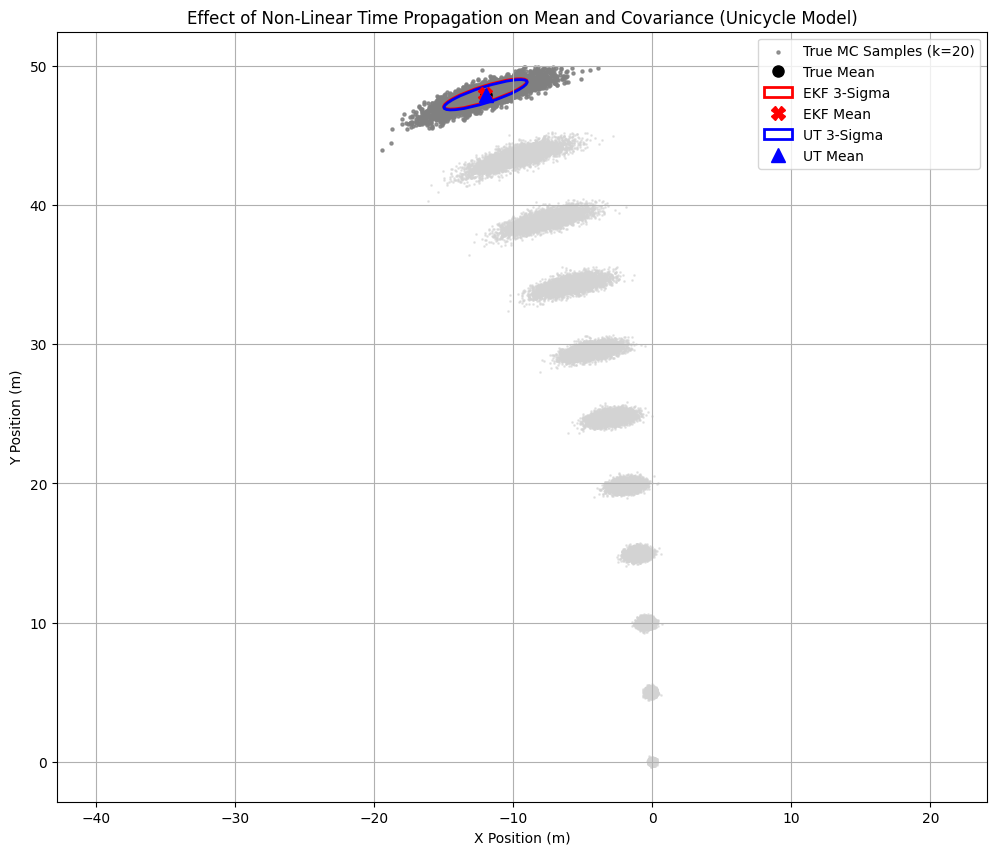

In [6]:
import matplotlib.patches as patches

def plot_covariance_ellipse(ax, mean, cov, color, label):
    """Plots a 2D covariance ellipse (3-sigma)"""
    # Use only x, y for plotting
    P_xy = cov[0:2, 0:2]
    eigvals, eigvecs = np.linalg.eigh(P_xy)
    angle = np.degrees(np.arctan2(eigvecs[1, 0], eigvecs[0, 0]))
    
    # 3-sigma ellipse
    width, height = 3 * np.sqrt(eigvals)
    ellipse = patches.Ellipse(xy=(mean[0], mean[1]), width=width, height=height, 
                              angle=angle, edgecolor=color, fc='None', lw=2, label=label)
    ax.add_patch(ellipse)


plt.figure(figsize=(12, 10))

# Plot intermediate steps lightly
for k in range(0, time_steps+1, 5):
    pts = mc_history[k]
    plt.scatter(pts[:, 0], pts[:, 1], s=1, color='lightgray', alpha=0.5)
    
# Plot final step clearly
final_mc = mc_history[-1]
plt.scatter(final_mc[:, 0], final_mc[:, 1], s=5, color='gray', alpha=0.8, label="True MC Samples (k=20)")

# Plot True Mean
plt.plot(true_final_mean[0], true_final_mean[1], 'ko', markersize=8, label="True Mean")

# Plot Final EKF Ellipse
plot_covariance_ellipse(plt.gca(), lin_mean_history[-1], lin_cov_history[-1], 'red', 'EKF 3-Sigma')
plt.plot(lin_mean_history[-1][0], lin_mean_history[-1][1], 'rX', markersize=10, label="EKF Mean")

# Plot Final UT Ellipse
plot_covariance_ellipse(plt.gca(), ut_mean_history[-1], ut_cov_history[-1], 'blue', 'UT 3-Sigma')
plt.plot(ut_mean_history[-1][0], ut_mean_history[-1][1], 'b^', markersize=10, label="UT Mean")

plt.title("Effect of Non-Linear Time Propagation on Mean and Covariance (Unicycle Model)")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

## 6.1. Final Distribution Focus

To make the effect even clearer, here is a zoomed-in plot of just the final step, comparing the True Mean & Covariance of the Monte Carlo points with the EKF and UT statistical estimates.

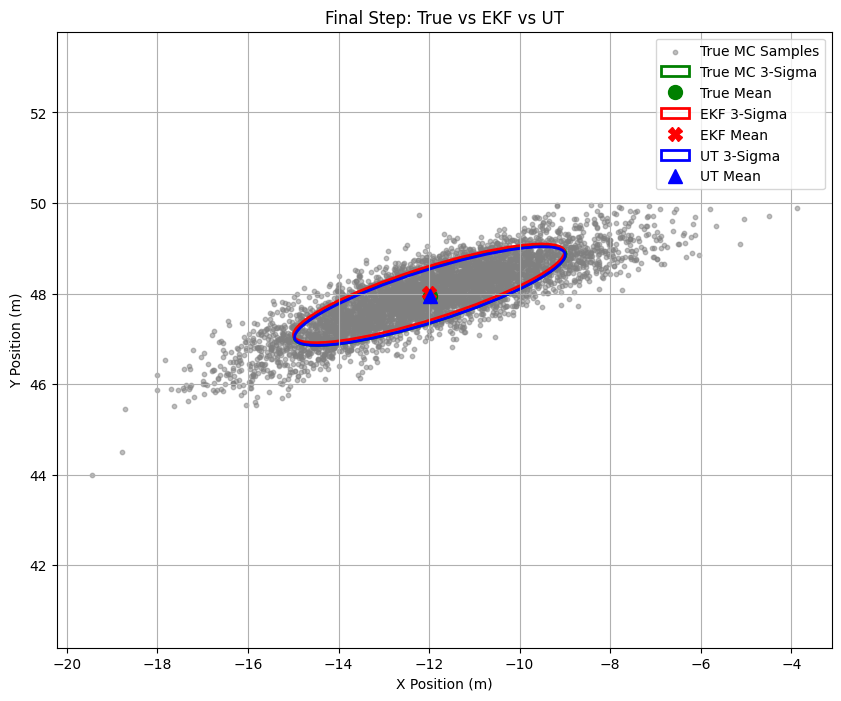

In [7]:
plt.figure(figsize=(10, 8))

# Plot only the final MC samples
plt.scatter(final_mc[:, 0], final_mc[:, 1], s=10, color='gray', alpha=0.5, label="True MC Samples")

# True Covariance Ellipse
plot_covariance_ellipse(plt.gca(), true_final_mean, true_final_cov, 'green', 'True MC 3-Sigma')
plt.plot(true_final_mean[0], true_final_mean[1], 'go', markersize=10, label="True Mean")

# EKF Ellipse
plot_covariance_ellipse(plt.gca(), lin_mean_history[-1], lin_cov_history[-1], 'red', 'EKF 3-Sigma')
plt.plot(lin_mean_history[-1][0], lin_mean_history[-1][1], 'rX', markersize=10, label="EKF Mean")

# UT Ellipse
plot_covariance_ellipse(plt.gca(), ut_mean_history[-1], ut_cov_history[-1], 'blue', 'UT 3-Sigma')
plt.plot(ut_mean_history[-1][0], ut_mean_history[-1][1], 'b^', markersize=10, label="UT Mean")

plt.title("Final Step: True vs EKF vs UT")
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

## 7. Challenge Problem
**Try it yourself:** 
1. Increase the initial heading uncertainty (`initial_cov` index `[2,2]`) from `0.05` to `.6` rad and re-run the simulation. Observe how wildly the EKF diverges while the UT attempts to capture the expanding banana!
2. Change the constant turn rate `omega` to `0.5` to tighten the turn radius.

### Solution: High Uncertainty Scenario

In this scenario, we increase the heading standard deviation to `0.6` rad and the turn rate to `0.5` rad/sec. 

**Observations:**
1. **EKF Divergence:** The EKF predicts a massive, symmetric ellipse. Because it linearizes around the mean, it assumes the growth in uncertainty is linear and symmetric in all directions. It fails to account for the geometry of the circular path.
2. **Banana Distribution:** The true distribution (Monte Carlo) clearly follows a curved arc. The spread is dominated by the angular uncertainty, which "wraps" the samples around the vehicle's turn radius.
3. **Mean Bias & Corner Cutting:** Notice that the EKF mean "cuts the corner"—it lies outside the dense cloud of Monte Carlo samples. In contrast, the UKF mean and the True Monte Carlo mean are "pulled" inward toward the center of the arc. This is because the average of points on a circular arc always lies inside the arc (a property captured by 2nd-order Taylor terms).
4. **Covariance Accuracy:** The UT covariance ellipse closely captures the orientation and centroid of the "banana" cloud, whereas the EKF ellipse is too centered on a point the vehicle is unlikely to be at.

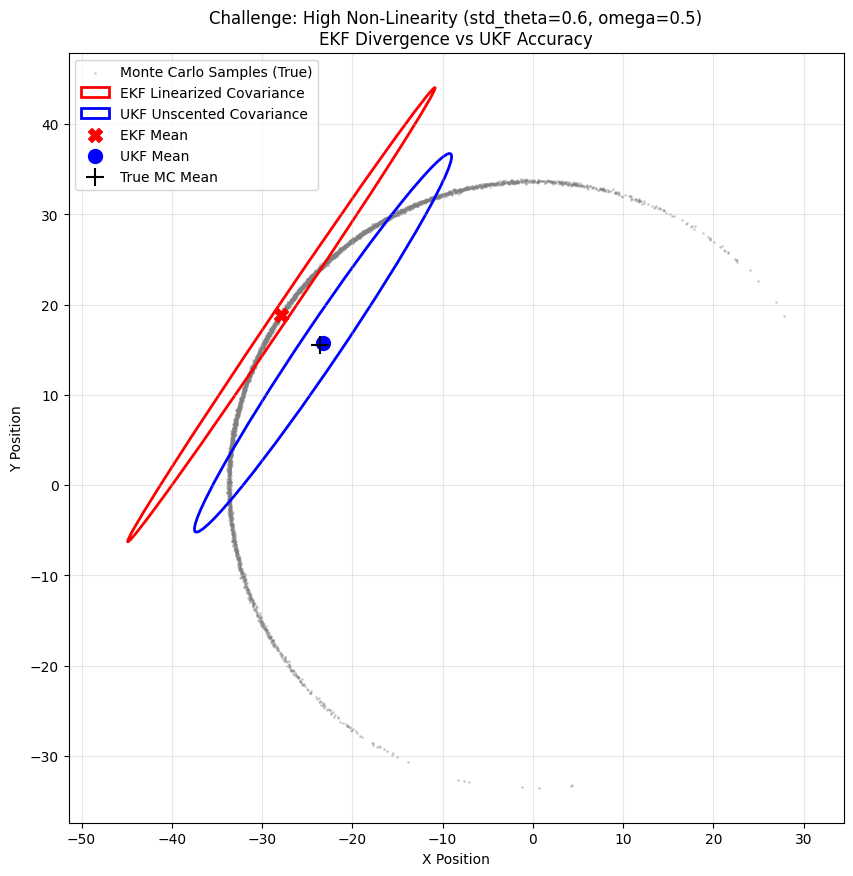

In [8]:
# --- Challenge Solution Implementation ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky

# 1. Update Parameters as per Challenge
dt_chal = 0.1
v_chal = 10.0
omega_chal = 0.5 # Increased turn rate (Task 2)
time_steps_chal = 40

# New initial covariance with high heading uncertainty (Task 1)
initial_mean_chal = np.array([0.0, 0.0, np.pi/2])
initial_cov_chal = np.diag([0.1**2, 0.1**2, 0.6**2]) 

# Process noise Q
Q_chal = np.diag([0.05**2, 0.05**2, 0.01**2])

# 2. Re-run True Monte Carlo
num_samples = 5000
mc_samples_chal = np.random.multivariate_normal(initial_mean_chal, initial_cov_chal, num_samples)

for k in range(time_steps_chal):
    for i in range(num_samples):
        x, y, th = mc_samples_chal[i]
        mc_samples_chal[i] = [x + v_chal*np.cos(th)*dt_chal, y + v_chal*np.sin(th)*dt_chal, th + omega_chal*dt_chal]
final_mc_chal = mc_samples_chal

# 3. Re-run EKF
ekf_m = initial_mean_chal.copy()
ekf_P = initial_cov_chal.copy()

for k in range(time_steps_chal):
    F = np.array([
        [1.0, 0.0, -v_chal * np.sin(ekf_m[2]) * dt_chal],
        [0.0, 1.0,  v_chal * np.cos(ekf_m[2]) * dt_chal],
        [0.0, 0.0,  1.0]
    ])
    # Propagate mean
    ekf_m = np.array([ekf_m[0] + v_chal*np.cos(ekf_m[2])*dt_chal, 
                      ekf_m[1] + v_chal*np.sin(ekf_m[2])*dt_chal, 
                      ekf_m[2] + omega_chal*dt_chal])
    ekf_P = F @ ekf_P @ F.T + Q_chal

# 4. Re-run UKF
n = 3
kappa = 3 - n
weights = np.array([kappa/(n+kappa)] + [1.0/(2*(n+kappa))] * (2*n))
uk_m = initial_mean_chal.copy()
uk_P = initial_cov_chal.copy()

for k in range(time_steps_chal):
    # Handle potential non-PSD issues with a tiny nudge if truncation errors accumulate
    L = cholesky(uk_P + np.eye(n)*1e-9, lower=True)
    sigpts = np.zeros((2*n+1, n))
    sigpts[0] = uk_m
    for i in range(n):
        sigpts[i+1]   = uk_m + np.sqrt(n+kappa)*L[:,i]
        sigpts[n+i+1] = uk_m - np.sqrt(n+kappa)*L[:,i]
    
    tsig = np.zeros_like(sigpts)
    for i in range(2*n+1):
        tsig[i,0] = sigpts[i,0] + v_chal*np.cos(sigpts[i,2])*dt_chal
        tsig[i,1] = sigpts[i,1] + v_chal*np.sin(sigpts[i,2])*dt_chal
        tsig[i,2] = sigpts[i,2] + omega_chal*dt_chal
    
    uk_m = np.sum(weights[:, None] * tsig, axis=0)
    uk_P = sum(weights[i] * np.outer(tsig[i]-uk_m, tsig[i]-uk_m) for i in range(2*n+1)) + Q_chal

# 5. Plotting results - Reuse plot_covariance_ellipse from cell 11
plt.figure(figsize=(10, 10))
plt.scatter(final_mc_chal[:,0], final_mc_chal[:,1], s=1, color='gray', alpha=0.3, label='Monte Carlo Samples (True)')

# Plot Covariance Ellipses
plot_covariance_ellipse(plt.gca(), ekf_m[:2], ekf_P[:2,:2], 'red', 'EKF Linearized Covariance')
plot_covariance_ellipse(plt.gca(), uk_m[:2], uk_P[:2,:2], 'blue', 'UKF Unscented Covariance')

# Plot Means
plt.scatter(ekf_m[0], ekf_m[1], color='red', marker='X', s=100, label='EKF Mean')
plt.scatter(uk_m[0], uk_m[1], color='blue', marker='o', s=100, label='UKF Mean')
mc_mean = np.mean(final_mc_chal, axis=0)
plt.scatter(mc_mean[0], mc_mean[1], color='black', marker='+', s=150, zorder=5, label='True MC Mean')

plt.title(f"Challenge: High Non-Linearity (std_theta=0.6, omega=0.5)\nEKF Divergence vs UKF Accuracy")
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()